# Convolutional Neural Networks (CNNs)

This notebook covers:
1. **Tensor image handling** - how images are represented and manipulated as tensors
2. **CNN theory** - convolutions, pooling, feature maps, and architecture design
3. **Fashion MNIST** - building, training, and evaluating a CNN from scratch
4. **Transfer Learning** - leveraging pre-trained models for new tasks

---
## Part 1: Tensor Image Handling

Before we can build a CNN, we need to understand how images are represented as tensors.

### What is an image to a computer?

An image is just a grid of numbers. Each number represents the intensity of a pixel.

- **Grayscale image**: a 2D grid of values (height x width), each pixel is a single intensity value (0 = black, 255 = white)
- **Color image (RGB)**: three 2D grids stacked together - one for Red, one for Green, one for Blue

### Tensor shape conventions

In PyTorch, image tensors follow the **CHW** convention:
- **C** = Channels (1 for grayscale, 3 for RGB)
- **H** = Height
- **W** = Width

A single RGB image of size 224x224 has shape: `(3, 224, 224)`

A batch of 32 such images has shape: `(32, 3, 224, 224)` - this is **NCHW** format:
- **N** = Batch size
- **C** = Channels
- **H** = Height
- **W** = Width

> **Note**: Other frameworks like TensorFlow use NHWC (channels last) by default. PyTorch uses NCHW (channels first). This is a common source of bugs when switching between frameworks.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Let's create some tensors to understand image shapes

# A single grayscale image: 1 channel, 28x28 pixels (like MNIST)
grayscale_image = torch.rand(1, 28, 28)
print(f"Grayscale image shape: {grayscale_image.shape}")
print(f"  - Channels: {grayscale_image.shape[0]}")
print(f"  - Height:   {grayscale_image.shape[1]}")
print(f"  - Width:    {grayscale_image.shape[2]}")
print()

# A single RGB image: 3 channels, 224x224 pixels
rgb_image = torch.rand(3, 224, 224)
print(f"RGB image shape: {rgb_image.shape}")
print(f"  - Channels: {rgb_image.shape[0]} (R, G, B)")
print(f"  - Height:   {rgb_image.shape[1]}")
print(f"  - Width:    {rgb_image.shape[2]}")
print()

# A batch of 32 RGB images
batch = torch.rand(32, 3, 224, 224)
print(f"Batch shape: {batch.shape}")
print(f"  - Batch size: {batch.shape[0]}")
print(f"  - Channels:   {batch.shape[1]}")
print(f"  - Height:     {batch.shape[2]}")
print(f"  - Width:      {batch.shape[3]}")

Grayscale image shape: torch.Size([1, 28, 28])
  - Channels: 1
  - Height:   28
  - Width:    28

RGB image shape: torch.Size([3, 224, 224])
  - Channels: 3 (R, G, B)
  - Height:   224
  - Width:    224

Batch shape: torch.Size([32, 3, 224, 224])
  - Batch size: 32
  - Channels:   3
  - Height:     224
  - Width:      224


### Transforms: From PIL Image to Tensor

When we load an image (from a file or a dataset), it typically comes as a **PIL Image** or a **numpy array** with shape `(H, W, C)` and pixel values in `[0, 255]`.

PyTorch needs tensors with shape `(C, H, W)` and (usually) values in `[0.0, 1.0]`.

The `transforms.ToTensor()` transform does both:
1. Converts from HWC to CHW (transposes the axes)
2. Scales pixel values from [0, 255] to [0.0, 1.0]

### Normalization

`transforms.Normalize(mean, std)` further normalizes each channel:

```
output[channel] = (input[channel] - mean[channel]) / std[channel]
```

This centers the data around 0 and scales it, which helps the network train faster and more stably. The mean and std values are typically computed from the training dataset.

In [3]:
# Demonstrating transforms

# Simulate a numpy image in HWC format (like what you'd get from cv2 or PIL)
numpy_image = np.random.randint(0, 256, size=(28, 28, 1), dtype=np.uint8)
print(f"Numpy image shape (HWC): {numpy_image.shape}")
print(f"Numpy image dtype: {numpy_image.dtype}")
print(f"Numpy pixel range: [{numpy_image.min()}, {numpy_image.max()}]")
print()

# Convert using ToTensor()
to_tensor = transforms.ToTensor()
tensor_image = to_tensor(numpy_image)
print(f"Tensor image shape (CHW): {tensor_image.shape}")
print(f"Tensor image dtype: {tensor_image.dtype}")
print(f"Tensor pixel range: [{tensor_image.min():.4f}, {tensor_image.max():.4f}]")
print()

# Normalize (for grayscale, single channel mean and std)
normalize = transforms.Normalize(mean=[0.5], std=[0.5])
normalized = normalize(tensor_image)
print(f"After normalization range: [{normalized.min():.4f}, {normalized.max():.4f}]")
print("Values are now centered around 0, roughly in [-1, 1]")

Numpy image shape (HWC): (28, 28, 1)
Numpy image dtype: uint8
Numpy pixel range: [0, 255]

Tensor image shape (CHW): torch.Size([1, 28, 28])
Tensor image dtype: torch.float32
Tensor pixel range: [0.0000, 1.0000]

After normalization range: [-1.0000, 1.0000]
Values are now centered around 0, roughly in [-1, 1]


In [4]:
# Composing transforms into a pipeline
# This is the standard way to build transform pipelines in PyTorch

transform_pipeline = transforms.Compose(
    [
        transforms.ToTensor(),  # PIL/numpy -> tensor, scale to [0,1]
        transforms.Normalize(mean=[0.5], std=[0.5]),  # center around 0
    ]
)

# For RGB images, you'd specify mean and std per channel:
rgb_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),  # resize to fixed size
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],  # ImageNet means
            std=[0.229, 0.224, 0.225],  # ImageNet stds
        ),
    ]
)

print("Transform pipelines created.")
print("These will be applied automatically when loading data from datasets.")

Transform pipelines created.
These will be applied automatically when loading data from datasets.


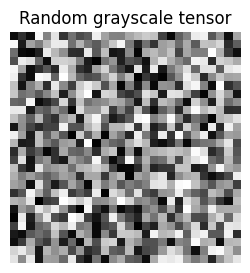

Tensor shape: torch.Size([1, 28, 28]) (CHW)
After permute for display: torch.Size([28, 28, 1]) (HWC)


In [5]:
# Visualizing tensors as images
# matplotlib expects images in HWC format with values in [0, 1]
# So we need to reverse the CHW -> HWC and potentially undo normalization


def show_tensor_image(tensor, title=None):
    """
    Display a tensor image.
    Expects tensor in CHW format.
    """
    # Clone so we don't modify the original
    img = tensor.clone().detach()

    # If it's a single image (no batch dim), add one for consistency
    if img.dim() == 3:
        # CHW -> HWC for matplotlib
        img = img.permute(1, 2, 0)

    # Clip to [0, 1] range for display
    img = img.clamp(0, 1)

    # If single channel, squeeze for matplotlib
    if img.shape[-1] == 1:
        img = img.squeeze(-1)

    plt.imshow(img.numpy(), cmap="gray" if img.dim() == 2 else None)
    if title:
        plt.title(title)
    plt.axis("off")


# Demo with a random grayscale image
random_img = torch.rand(1, 28, 28)
plt.figure(figsize=(3, 3))
show_tensor_image(random_img, "Random grayscale tensor")
plt.show()

print(f"Tensor shape: {random_img.shape} (CHW)")
print(f"After permute for display: {random_img.permute(1, 2, 0).shape} (HWC)")

### Key takeaways for tensor image handling

| Concept | Detail |
|---------|--------|
| PyTorch format | `(N, C, H, W)` - batch, channels, height, width |
| `ToTensor()` | Converts HWC uint8 [0,255] to CHW float32 [0,1] |
| `Normalize(mean, std)` | `(x - mean) / std` per channel |
| matplotlib expects | HWC format - use `.permute(1, 2, 0)` to convert |
| Grayscale | 1 channel |
| RGB | 3 channels (Red, Green, Blue) |

---
## Part 2: CNN Theory

### Why not just use a fully connected (dense) network for images?

A 224x224 RGB image has **224 x 224 x 3 = 150,528 pixels**. If the first hidden layer had 1000 neurons, that's **150 million parameters** in just the first layer. This is:
- Extremely expensive to compute
- Very prone to overfitting
- Ignores the spatial structure of images (a pixel's meaning depends on its neighbors)

### The key insight of CNNs

CNNs exploit three important properties of images:

1. **Local connectivity**: A pixel is most related to its nearby pixels. We don't need every neuron connected to every pixel.
2. **Translation invariance**: A cat in the top-left corner is still a cat in the bottom-right. The same feature detector should work everywhere.
3. **Hierarchical features**: Simple features (edges) combine into complex features (textures -> parts -> objects).

### The Convolution Operation

A convolution slides a small **filter** (also called a **kernel**) across the image, computing dot products at each position.

```
Input image (5x5):          Filter (3x3):         Output (3x3):

1  2  3  4  5               1  0  1                
6  7  8  9  10              0  1  0              For each position, multiply
11 12 13 14 15              1  0  1              element-wise and sum.
16 17 18 19 20
21 22 23 24 25
```

The filter slides across the image. At each position, we:
1. Overlay the filter on the image patch
2. Multiply corresponding elements
3. Sum all the products
4. That sum becomes one pixel in the output

### Terminology

- **Filter/Kernel**: The small matrix of learnable weights (e.g., 3x3, 5x5)
- **Feature map**: The output of applying one filter to the input. Also called an activation map.
- **Stride**: How many pixels the filter moves at each step. Stride=1 means move 1 pixel at a time.
- **Padding**: Adding zeros around the border of the input to control the output size.
  - `padding=0` (valid): output shrinks
  - `padding='same'`: output stays the same size as input
- **Number of filters**: Each filter learns to detect a different feature. More filters = more features detected.

Input image (8x8, left=black, right=white):
[[0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1.]]


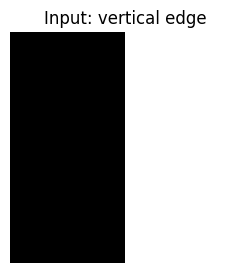

In [6]:
# Let's see convolution in action with a manual filter

# Create a simple 1-channel 8x8 image with a vertical edge
simple_image = torch.zeros(1, 1, 8, 8)  # (N, C, H, W)
simple_image[:, :, :, 4:] = 1.0  # right half is white

print("Input image (8x8, left=black, right=white):")
print(simple_image.squeeze().numpy())

plt.figure(figsize=(3, 3))
plt.imshow(simple_image.squeeze().numpy(), cmap="gray")
plt.title("Input: vertical edge")
plt.axis("off")
plt.show()

Filter shape: torch.Size([1, 1, 3, 3])
Filter values:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

Output shape: torch.Size([1, 1, 6, 6])
Output (notice the edge is detected as a bright vertical line):
[[0. 0. 3. 3. 0. 0.]
 [0. 0. 3. 3. 0. 0.]
 [0. 0. 3. 3. 0. 0.]
 [0. 0. 3. 3. 0. 0.]
 [0. 0. 3. 3. 0. 0.]
 [0. 0. 3. 3. 0. 0.]]


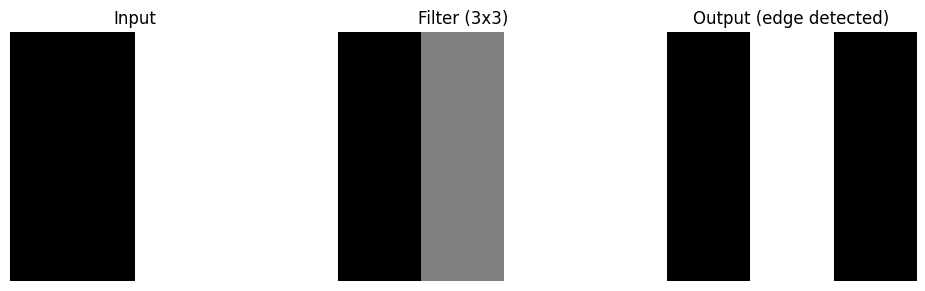

In [7]:
# Apply a vertical edge detection filter manually
# This filter detects transitions from dark to light (left to right)

edge_filter = torch.tensor(
    [[[[-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0]]]]
)  # shape: (out_channels=1, in_channels=1, kH=3, kW=3)

print(f"Filter shape: {edge_filter.shape}")
print(f"Filter values:\n{edge_filter.squeeze().numpy()}")
print()

# Apply convolution
output = F.conv2d(simple_image, edge_filter, padding=0)
print(f"Output shape: {output.shape}")
print(f"Output (notice the edge is detected as a bright vertical line):")
print(output.squeeze().numpy())

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(simple_image.squeeze().numpy(), cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(edge_filter.squeeze().numpy(), cmap="gray")
axes[1].set_title("Filter (3x3)")
axes[1].axis("off")

axes[2].imshow(output.squeeze().numpy(), cmap="gray")
axes[2].set_title("Output (edge detected)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Output size formula

Given an input of size `H_in`, filter size `k`, padding `p`, and stride `s`:

$$H_{out} = \lfloor \frac{H_{in} + 2p - k}{s} \rfloor + 1$$

For our example above:
- Input: 8x8, Filter: 3x3, Padding: 0, Stride: 1
- Output: (8 + 0 - 3) / 1 + 1 = **6x6**

In [8]:
# Understanding output sizes with different padding and stride

dummy = torch.rand(1, 1, 28, 28)  # MNIST-sized input

# No padding, stride 1
conv_no_pad = nn.Conv2d(
    in_channels=1, out_channels=1, kernel_size=3, padding=0, stride=1
)
out1 = conv_no_pad(dummy)
print(
    f"Input: 28x28, kernel=3, pad=0, stride=1 -> Output: {out1.shape[2]}x{out1.shape[3]}"
)

# Padding 1, stride 1 (same padding for kernel_size=3)
conv_same = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, stride=1)
out2 = conv_same(dummy)
print(
    f"Input: 28x28, kernel=3, pad=1, stride=1 -> Output: {out2.shape[2]}x{out2.shape[3]}"
)

# Stride 2 (downsamples by factor of 2)
conv_stride = nn.Conv2d(
    in_channels=1, out_channels=1, kernel_size=3, padding=1, stride=2
)
out3 = conv_stride(dummy)
print(
    f"Input: 28x28, kernel=3, pad=1, stride=2 -> Output: {out3.shape[2]}x{out3.shape[3]}"
)

# Larger kernel
conv_large = nn.Conv2d(
    in_channels=1, out_channels=1, kernel_size=5, padding=2, stride=1
)
out4 = conv_large(dummy)
print(
    f"Input: 28x28, kernel=5, pad=2, stride=1 -> Output: {out4.shape[2]}x{out4.shape[3]}"
)

Input: 28x28, kernel=3, pad=0, stride=1 -> Output: 26x26
Input: 28x28, kernel=3, pad=1, stride=1 -> Output: 28x28
Input: 28x28, kernel=3, pad=1, stride=2 -> Output: 14x14
Input: 28x28, kernel=5, pad=2, stride=1 -> Output: 28x28


### Multiple Filters = Multiple Feature Maps

A `Conv2d(in_channels=1, out_channels=16, kernel_size=3)` layer has **16 separate 3x3 filters**. Each filter produces its own feature map, so the output has 16 channels.

In early layers, filters learn to detect low-level features like edges, corners, and textures. In deeper layers, they combine these into higher-level features.

### Pooling

**Pooling** reduces the spatial dimensions (H and W) while keeping the number of channels. This:
- Reduces computation
- Provides a form of translation invariance (small shifts don't change the output)
- Prevents overfitting

**Max Pooling** takes the maximum value in each local window:
```
Input (4x4):            MaxPool2d(2):  Output (2x2):

1  3  2  4              max(1,3,5,7)=7    max(2,4,6,8)=8
5  7  6  8     -->      max(9,11,13,15)=15 max(10,12,14,16)=16
9  11 10 12
13 15 14 16
```

**Average Pooling** takes the mean instead of the max.

In [9]:
# Pooling demonstration

pool_input = torch.tensor(
    [
        [
            [
                [1.0, 3.0, 2.0, 4.0],
                [5.0, 7.0, 6.0, 8.0],
                [9.0, 11.0, 10.0, 12.0],
                [13.0, 15.0, 14.0, 16.0],
            ]
        ]
    ]
)  # (N=1, C=1, H=4, W=4)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

max_out = max_pool(pool_input)
avg_out = avg_pool(pool_input)

print(f"Input (4x4):\n{pool_input.squeeze().numpy()}")
print(f"\nMax pooling (2x2):\n{max_out.squeeze().numpy()}")
print(f"\nAvg pooling (2x2):\n{avg_out.squeeze().numpy()}")
print(f"\nShape: {pool_input.shape} -> {max_out.shape} (halved spatial dims)")

Input (4x4):
[[ 1.  3.  2.  4.]
 [ 5.  7.  6.  8.]
 [ 9. 11. 10. 12.]
 [13. 15. 14. 16.]]

Max pooling (2x2):
[[ 7.  8.]
 [15. 16.]]

Avg pooling (2x2):
[[ 4.  5.]
 [12. 13.]]

Shape: torch.Size([1, 1, 4, 4]) -> torch.Size([1, 1, 2, 2]) (halved spatial dims)


### Typical CNN Architecture

A standard CNN alternates between convolution blocks and pooling, then ends with fully connected layers:

```
Input Image (1, 28, 28)
    |
    v
[Conv2d + ReLU]  --> extract features (e.g., 32 filters)
    |
    v
[MaxPool2d]      --> reduce spatial size
    |
    v
[Conv2d + ReLU]  --> extract higher-level features (e.g., 64 filters)
    |
    v
[MaxPool2d]      --> reduce spatial size again
    |
    v
[Flatten]        --> convert 2D feature maps to 1D vector
    |
    v
[Linear + ReLU]  --> fully connected layer
    |
    v
[Linear]         --> output layer (num_classes outputs)
```

Key pattern: **spatial dimensions decrease** (through pooling) while **depth (channels) increases** (through more filters). This progressively compresses spatial information into feature representations.

---
## Part 3: Fashion MNIST with a CNN

Fashion MNIST is a drop-in replacement for the classic MNIST dataset. Instead of handwritten digits, it contains **10 categories of clothing items**:

| Label | Class |
|-------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Each image is 28x28 grayscale, same as MNIST.

In [10]:
# Define transforms
# ToTensor: converts PIL image (H,W) to tensor (C,H,W) and scales to [0,1]
# Normalize: centers around 0 with std 1 (0.5 is approx mean/std for Fashion MNIST)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),  # Fashion MNIST mean and std
    ]
)

# Download and load the datasets
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

print(f"Training set: {len(train_dataset)} images")
print(f"Test set:     {len(test_dataset)} images")

# Look at a single sample
image, label = train_dataset[0]
print(f"\nSingle image tensor shape: {image.shape}")
print(
    f"  - This is (C, H, W) = ({image.shape[0]} channel, {image.shape[1]}x{image.shape[2]} pixels)"
)
print(f"Label: {label}")

100.0%
100.0%
100.0%
100.0%

Training set: 60000 images
Test set:     10000 images

Single image tensor shape: torch.Size([1, 28, 28])
  - This is (C, H, W) = (1 channel, 28x28 pixels)
Label: 9


In [11]:
# Create data loaders - these handle batching, shuffling, and parallel loading

BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # shuffle training data each epoch
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # no need to shuffle test data
)

# Get one batch to inspect
images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(
    f"  -> (batch_size={images.shape[0]}, channels={images.shape[1]}, H={images.shape[2]}, W={images.shape[3]})"
)
print(f"Batch of labels shape: {labels.shape}")
print(f"Labels: {labels[:10]}")

Batch of images shape: torch.Size([64, 1, 28, 28])
  -> (batch_size=64, channels=1, H=28, W=28)
Batch of labels shape: torch.Size([64])
Labels: tensor([1, 0, 8, 2, 2, 5, 7, 5, 3, 3])


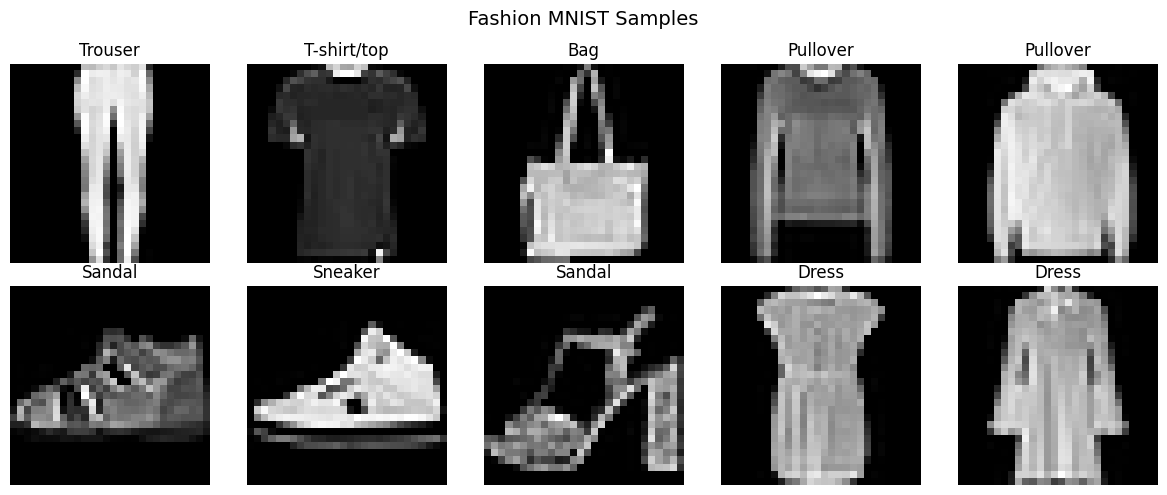

In [12]:
# Visualize some samples

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # Undo normalization for display: x * std + mean
    img = images[i].squeeze() * 0.3530 + 0.2860
    ax.imshow(img.numpy(), cmap="gray")
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.suptitle("Fashion MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()

### Building the CNN model

Let's trace the tensor shapes through our network:

```
Input:          (N, 1, 28, 28)    -- 1 channel grayscale
Conv1(1->32):   (N, 32, 26, 26)   -- 32 filters, no padding: 28-3+1=26
ReLU:           (N, 32, 26, 26)   -- same shape
MaxPool(2):     (N, 32, 13, 13)   -- halve spatial: 26/2=13
Conv2(32->64):  (N, 64, 11, 11)   -- 64 filters: 13-3+1=11
ReLU:           (N, 64, 11, 11)   -- same shape
MaxPool(2):     (N, 64, 5, 5)     -- halve spatial: 11/2=5 (floor)
Flatten:        (N, 64*5*5=1600)  -- flatten to 1D
Linear(1600->128): (N, 128)       -- fully connected
ReLU:           (N, 128)
Linear(128->10): (N, 10)          -- 10 classes
```

In [13]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(
            in_channels=1,  # grayscale input
            out_channels=32,  # 32 filters
            kernel_size=3,  # 3x3 filters
            padding=0,  # no padding
        )
        self.conv2 = nn.Conv2d(
            in_channels=32,  # input from previous layer
            out_channels=64,  # 64 filters
            kernel_size=3,
            padding=0,
        )

        # Pooling layer (same one can be reused - it has no parameters)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # After conv1(28->26) -> pool(26->13) -> conv2(13->11) -> pool(11->5)
        # Feature map size: 64 channels * 5 * 5 = 1600
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

        # Dropout for regularization
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # x shape: (N, 1, 28, 28)

        # First conv block
        x = self.conv1(x)  # (N, 32, 26, 26)
        x = F.relu(x)  # (N, 32, 26, 26)
        x = self.pool(x)  # (N, 32, 13, 13)

        # Second conv block
        x = self.conv2(x)  # (N, 64, 11, 11)
        x = F.relu(x)  # (N, 64, 11, 11)
        x = self.pool(x)  # (N, 64, 5, 5)

        # Flatten: reshape from (N, 64, 5, 5) to (N, 1600)
        x = x.view(x.size(0), -1)  # or: x = torch.flatten(x, 1)

        # Fully connected layers
        x = self.fc1(x)  # (N, 128)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)  # (N, 10)

        return x  # raw logits (CrossEntropyLoss applies softmax internally)


# Create model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FashionCNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cpu
FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

Total parameters: 225,034


In [14]:
# Verify shapes by passing a dummy input through the model

dummy_input = torch.rand(1, 1, 28, 28).to(device)
dummy_output = model(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}  (10 class scores)")

Input shape:  torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])  (10 class scores)


In [15]:
# Loss function and optimizer

# CrossEntropyLoss combines LogSoftmax + NLLLoss
# It expects raw logits (not softmax output)
criterion = nn.CrossEntropyLoss()

# Adam optimizer with a reasonable learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
# Training loop

NUM_EPOCHS = 10

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()  # enable dropout, batch norm in training mode
    running_loss = 0.0

    for batch_images, batch_labels in train_loader:
        # Move data to device
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass
        outputs = model(batch_images)  # (N, 10)
        loss = criterion(outputs, batch_labels)

        # Backward pass and optimize
        optimizer.zero_grad()  # clear previous gradients
        loss.backward()  # compute gradients
        optimizer.step()  # update weights

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Evaluation phase ---
    model.eval()  # disable dropout, batch norm in eval mode
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no need to track gradients during evaluation
        for batch_images, batch_labels in test_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item()

            # Get predictions (class with highest score)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct / total
    test_losses.append(avg_test_loss)
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f}  "
        f"Test Loss: {avg_test_loss:.4f}  "
        f"Test Accuracy: {test_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.4881  Test Loss: 0.3467  Test Accuracy: 86.96%
Epoch [2/10] Train Loss: 0.3223  Test Loss: 0.2888  Test Accuracy: 89.53%
Epoch [3/10] Train Loss: 0.2770  Test Loss: 0.2713  Test Accuracy: 90.07%
Epoch [4/10] Train Loss: 0.2458  Test Loss: 0.2604  Test Accuracy: 90.47%
Epoch [5/10] Train Loss: 0.2224  Test Loss: 0.2526  Test Accuracy: 90.97%
Epoch [6/10] Train Loss: 0.2043  Test Loss: 0.2333  Test Accuracy: 91.37%
Epoch [7/10] Train Loss: 0.1873  Test Loss: 0.2424  Test Accuracy: 91.22%
Epoch [8/10] Train Loss: 0.1708  Test Loss: 0.2414  Test Accuracy: 91.52%
Epoch [9/10] Train Loss: 0.1590  Test Loss: 0.2371  Test Accuracy: 91.90%
Epoch [10/10] Train Loss: 0.1460  Test Loss: 0.2622  Test Accuracy: 91.68%


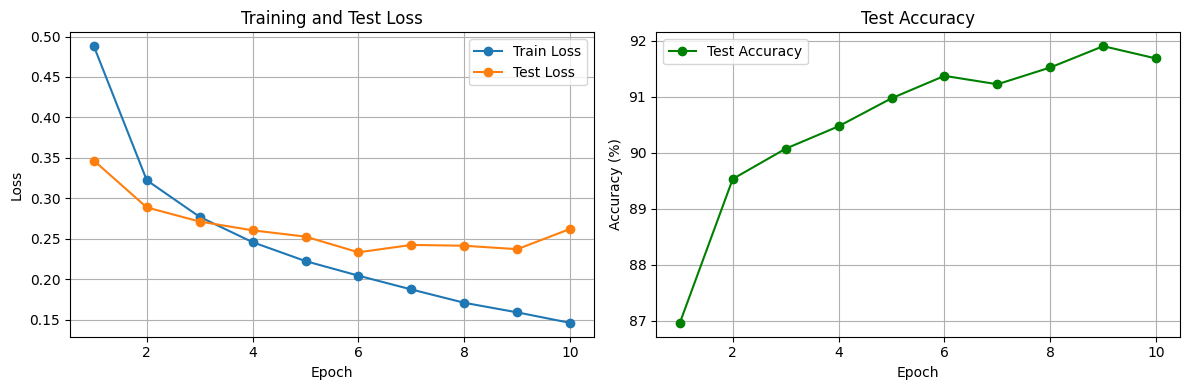

In [17]:
# Plot training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker="o")
ax1.plot(range(1, NUM_EPOCHS + 1), test_losses, label="Test Loss", marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Test Loss")
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(
    range(1, NUM_EPOCHS + 1),
    test_accuracies,
    label="Test Accuracy",
    marker="o",
    color="green",
)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Test Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

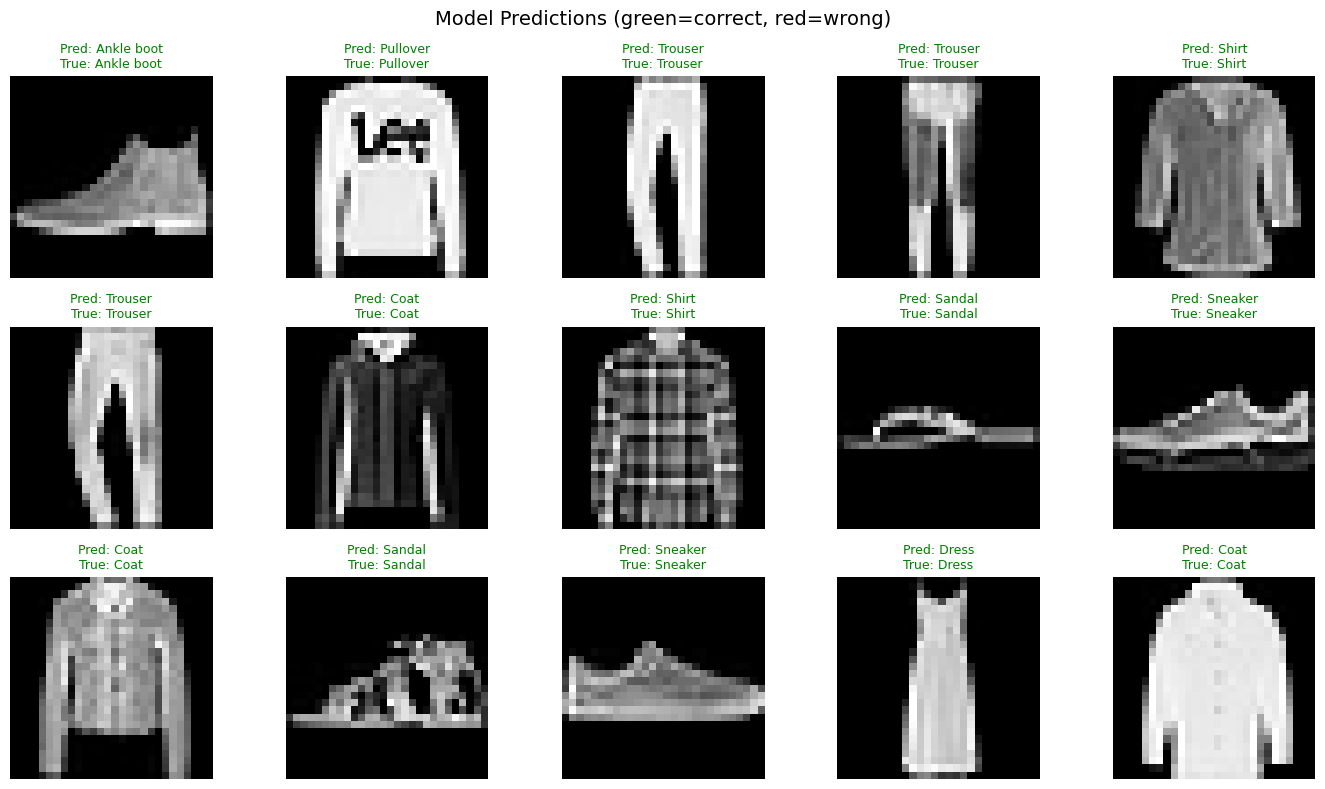

In [18]:
# Visualize predictions on test samples

model.eval()
test_images, test_labels = next(iter(test_loader))
test_images_device = test_images.to(device)

with torch.no_grad():
    outputs = model(test_images_device)
    _, predictions = torch.max(outputs, 1)

predictions = predictions.cpu()

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    # Undo normalization for display
    img = test_images[i].squeeze() * 0.3530 + 0.2860
    ax.imshow(img.numpy(), cmap="gray")

    pred_label = class_names[predictions[i]]
    true_label = class_names[test_labels[i]]
    color = "green" if predictions[i] == test_labels[i] else "red"

    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=9)
    ax.axis("off")

plt.suptitle("Model Predictions (green=correct, red=wrong)", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Per-class accuracy

class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

print("Per-class accuracy:")
print("-" * 35)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{class_names[i]:<15} {acc:>6.2f}%")

Per-class accuracy:
-----------------------------------
T-shirt/top      83.70%
Trouser          97.80%
Pullover         88.20%
Dress            94.30%
Coat             86.60%
Sandal           98.80%
Shirt            76.90%
Sneaker          96.80%
Bag              97.70%
Ankle boot       96.00%


### What we learned from Fashion MNIST

- CNNs work well even on small 28x28 images
- The model learns to distinguish between clothing categories using spatial features
- Some classes are harder than others (e.g., Shirt vs T-shirt/top vs Pullover look similar)
- A simple 2-layer CNN can achieve ~90% accuracy on this dataset
- The tensor shape flows are critical to track: `(N, C, H, W)` throughout the conv layers, then flatten to `(N, features)` for the linear layers

---
## Part 4: Transfer Learning

### What is Transfer Learning?

Transfer learning is the practice of **reusing a model trained on one task as the starting point for a model on a different task**.

The core idea: a CNN trained on ImageNet (1.2 million images, 1000 classes) has already learned to detect a rich hierarchy of visual features:

```
Early layers:  edges, corners, colors, textures
Middle layers: patterns, parts (eyes, wheels, fabric textures)
Late layers:   object-specific features (dog faces, car bodies)
```

These features are **general-purpose** - edges and textures are useful for almost any vision task. So instead of training from scratch, we can:

1. Take a pre-trained model (e.g., ResNet, VGG, EfficientNet)
2. Replace the final classification layer to match our number of classes
3. Fine-tune on our dataset

### Why Transfer Learning?

| From Scratch | Transfer Learning |
|---|---|
| Need lots of data (>10,000 images) | Works with few images (even 100s) |
| Takes hours/days to train | Converges in minutes |
| Random initialization | Starts with useful features |
| Must learn everything | Only needs to learn task-specific features |

### Two strategies

**Strategy 1: Feature Extraction (freeze the backbone)**
- Freeze all pre-trained layers (no gradient updates)
- Only train the new classification head
- Best when: you have very little data, or your task is similar to ImageNet

**Strategy 2: Fine-tuning (unfreeze some/all layers)**
- Start with frozen backbone, train the head
- Then unfreeze some or all backbone layers and train with a small learning rate
- Best when: you have moderate data, or your task differs from ImageNet

### Important considerations

- **Input size**: Pre-trained models expect specific input sizes (e.g., 224x224 for ResNet)
- **Normalization**: You must use the same normalization the model was trained with (ImageNet mean/std)
- **Learning rate**: Use a much smaller learning rate when fine-tuning (e.g., 1e-4 instead of 1e-2)
- **Channels**: Pre-trained models expect 3-channel (RGB) input. For grayscale, you need to convert (e.g., repeat the channel 3 times)

In [20]:
# Transfer Learning Example: Using a pre-trained ResNet18 for Fashion MNIST
#
# Challenge: Fashion MNIST is 28x28 grayscale (1 channel)
# ResNet18 expects 224x224 RGB (3 channels)
# We need to adapt the data to match.

from torchvision import models

# Step 1: Prepare transforms that match what ResNet expects
# - Resize to 224x224
# - Convert grayscale to 3 channels (by repeating)
# - Normalize with ImageNet statistics

transfer_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),  # repeat grayscale to 3 channels
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],  # ImageNet means
            std=[0.229, 0.224, 0.225],  # ImageNet stds
        ),
    ]
)

print("Transform pipeline for transfer learning:")
print("  1. Resize 28x28 -> 224x224")
print("  2. Grayscale 1ch -> 3ch (duplicate channels)")
print("  3. ToTensor: HWC uint8 -> CHW float32")
print("  4. Normalize with ImageNet stats")

Transform pipeline for transfer learning:
  1. Resize 28x28 -> 224x224
  2. Grayscale 1ch -> 3ch (duplicate channels)
  3. ToTensor: HWC uint8 -> CHW float32
  4. Normalize with ImageNet stats


In [21]:
# Load datasets with transfer learning transforms
# Using a smaller subset for speed (transfer learning works great with less data)

transfer_train = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transfer_transform
)
transfer_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transfer_transform
)

# Use a subset for faster training (transfer learning doesn't need as much data)
train_subset = torch.utils.data.Subset(transfer_train, range(5000))
test_subset = torch.utils.data.Subset(transfer_test, range(1000))

transfer_train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=32, shuffle=True
)
transfer_test_loader = torch.utils.data.DataLoader(
    test_subset, batch_size=32, shuffle=False
)

# Verify shapes
sample_img, sample_lbl = transfer_train[0]
print(f"Transformed image shape: {sample_img.shape}")
print(
    f"  -> (C={sample_img.shape[0]}, H={sample_img.shape[1]}, W={sample_img.shape[2]})"
)
print(f"Training subset size: {len(train_subset)}")
print(f"Test subset size: {len(test_subset)}")

Transformed image shape: torch.Size([3, 224, 224])
  -> (C=3, H=224, W=224)
Training subset size: 5000
Test subset size: 1000


In [22]:
# Step 2: Load pre-trained ResNet18 and modify it

# Load ResNet18 with pre-trained ImageNet weights
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Let's look at the last layer
print(f"Original final layer: {resnet.fc}")
print(f"  -> This outputs 1000 classes (ImageNet)")
print()

# Replace the final fully connected layer
# ResNet18's fc layer input features = 512
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)  # 10 Fashion MNIST classes

print(f"New final layer: {resnet.fc}")
print(f"  -> This outputs 10 classes (Fashion MNIST)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/santa/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Original final layer: Linear(in_features=512, out_features=1000, bias=True)
  -> This outputs 1000 classes (ImageNet)

New final layer: Linear(in_features=512, out_features=10, bias=True)
  -> This outputs 10 classes (Fashion MNIST)


In [23]:
# Step 3: Freeze the backbone (feature extraction strategy)
# We only want to train the new fc layer, not the pre-trained conv layers

# Freeze all parameters first
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze the final layer (the one we just replaced)
for param in resnet.fc.parameters():
    param.requires_grad = True

# Count trainable vs total parameters
total_params = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:>10,}")
print(
    f"Frozen parameters:    {frozen_params:>10,} ({100 * frozen_params / total_params:.1f}%)"
)
print(
    f"Trainable parameters: {trainable_params:>10,} ({100 * trainable_params / total_params:.1f}%)"
)
print()
print("We're only training the final classification layer!")
print("All the learned features from ImageNet are preserved.")

Total parameters:     11,181,642
Frozen parameters:    11,176,512 (100.0%)
Trainable parameters:      5,130 (0.0%)

We're only training the final classification layer!
All the learned features from ImageNet are preserved.


In [24]:
# Step 4: Train the transfer learning model

resnet = resnet.to(device)
criterion_tl = nn.CrossEntropyLoss()

# Only optimize the parameters that require gradients (the fc layer)
optimizer_tl = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.001
)

TL_EPOCHS = 5
tl_train_losses = []
tl_test_accuracies = []

for epoch in range(TL_EPOCHS):
    # Training
    resnet.train()
    running_loss = 0.0

    for batch_images, batch_labels in transfer_train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs = resnet(batch_images)
        loss = criterion_tl(outputs, batch_labels)

        optimizer_tl.zero_grad()
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(transfer_train_loader)
    tl_train_losses.append(avg_loss)

    # Evaluation
    resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_images, batch_labels in transfer_test_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            outputs = resnet(batch_images)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total
    tl_test_accuracies.append(accuracy)

    print(
        f"Epoch [{epoch + 1}/{TL_EPOCHS}] "
        f"Loss: {avg_loss:.4f}  "
        f"Test Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5] Loss: 1.1830  Test Accuracy: 78.80%
Epoch [2/5] Loss: 0.6469  Test Accuracy: 81.80%
Epoch [3/5] Loss: 0.5532  Test Accuracy: 82.80%
Epoch [4/5] Loss: 0.5035  Test Accuracy: 82.70%
Epoch [5/5] Loss: 0.4749  Test Accuracy: 83.10%


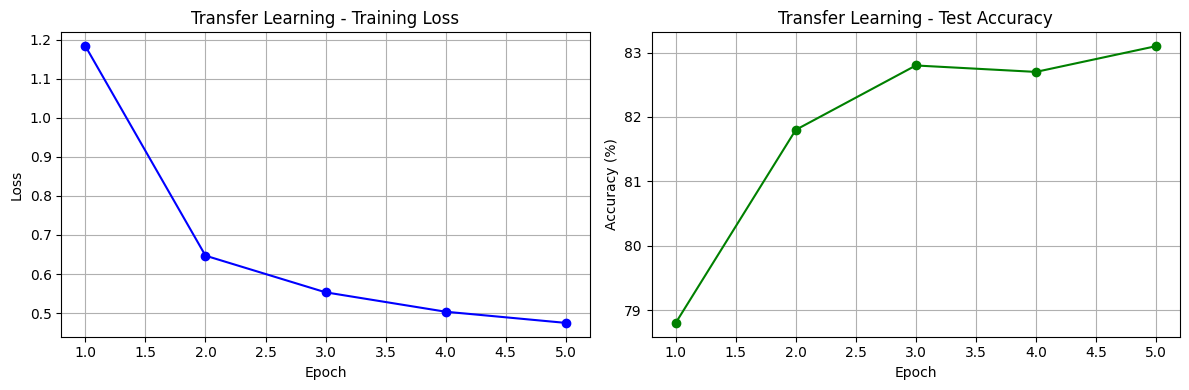


Final accuracy with transfer learning: 83.10%
Achieved with only 5000 training samples and 5 epochs!


In [25]:
# Plot transfer learning results

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, TL_EPOCHS + 1), tl_train_losses, marker="o", color="blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Transfer Learning - Training Loss")
ax1.grid(True)

ax2.plot(range(1, TL_EPOCHS + 1), tl_test_accuracies, marker="o", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Transfer Learning - Test Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal accuracy with transfer learning: {tl_test_accuracies[-1]:.2f}%")
print(
    f"Achieved with only {len(train_subset)} training samples and {TL_EPOCHS} epochs!"
)

### Fine-tuning: Unfreezing the backbone

After training just the head, we can optionally unfreeze some backbone layers and continue training with a smaller learning rate. This lets the pre-trained features adapt to our specific dataset.

In [26]:
# Fine-tuning: unfreeze the last residual block (layer4) and the fc layer

# Unfreeze layer4
for param in resnet.layer4.parameters():
    param.requires_grad = True

# Recount parameters
trainable_now = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Trainable parameters after unfreezing layer4: {trainable_now:,}")
print(f"(was {trainable_params:,} with only fc layer)")
print()

# Use a smaller learning rate for fine-tuning
# Different learning rates for different parts:
optimizer_ft = torch.optim.Adam(
    [
        {
            "params": resnet.layer4.parameters(),
            "lr": 1e-4,
        },  # small lr for pre-trained layers
        {"params": resnet.fc.parameters(), "lr": 1e-3},  # larger lr for new layer
    ]
)

print("Fine-tuning with differential learning rates:")
print("  - layer4 (pre-trained): lr=0.0001")
print("  - fc (new):             lr=0.001")

# Train for a few more epochs
FT_EPOCHS = 3

for epoch in range(FT_EPOCHS):
    resnet.train()
    running_loss = 0.0

    for batch_images, batch_labels in transfer_train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs = resnet(batch_images)
        loss = criterion_tl(outputs, batch_labels)

        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()

        running_loss += loss.item()

    # Evaluate
    resnet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_images, batch_labels in transfer_test_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            outputs = resnet(batch_images)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(transfer_train_loader)

    print(
        f"Fine-tune Epoch [{epoch + 1}/{FT_EPOCHS}] "
        f"Loss: {avg_loss:.4f}  "
        f"Test Accuracy: {accuracy:.2f}%"
    )

Trainable parameters after unfreezing layer4: 8,398,858
(was 5,130 with only fc layer)

Fine-tuning with differential learning rates:
  - layer4 (pre-trained): lr=0.0001
  - fc (new):             lr=0.001
Fine-tune Epoch [1/3] Loss: 0.4069  Test Accuracy: 88.40%
Fine-tune Epoch [2/3] Loss: 0.1293  Test Accuracy: 89.80%
Fine-tune Epoch [3/3] Loss: 0.0547  Test Accuracy: 89.20%


### Transfer Learning Summary

```
                    From Scratch CNN          Transfer Learning
                    ----------------          -----------------
Training data       60,000 images             5,000 images (subset)
Epochs              10                        5 + 3 fine-tuning
Architecture        2 conv layers             ResNet18 (18 layers)
Pre-trained         No                        Yes (ImageNet)
Trainable params    ~110K (all)               ~5K (head) -> ~2.4M (fine-tune)
```

### When to use each strategy

| Scenario | Strategy |
|----------|----------|
| Very small dataset (<1000 images) | Feature extraction (frozen backbone) |
| Small dataset, similar to ImageNet | Feature extraction, maybe fine-tune last block |
| Medium dataset, different from ImageNet | Fine-tune most of the network |
| Large dataset | Fine-tune everything, or train from scratch |

### Common pre-trained models in `torchvision.models`

| Model | Parameters | Top-1 Accuracy (ImageNet) | Use case |
|-------|-----------|--------------------------|----------|
| ResNet18 | 11.7M | 69.8% | Fast prototyping, smaller tasks |
| ResNet50 | 25.6M | 76.1% | Good balance of speed and accuracy |
| VGG16 | 138M | 71.6% | Simple architecture, easy to understand |
| EfficientNet-B0 | 5.3M | 77.7% | Best accuracy per parameter |
| MobileNetV3 | 5.4M | 75.2% | Mobile/edge deployment |

### Key code pattern for transfer learning

```python
# 1. Load pre-trained model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Replace the head
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 3. Freeze backbone (optional)
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

# 4. Use ImageNet normalization in transforms
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 5. Train with small learning rate
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
```